# Holosoma Laplacian Hessian 谱性质诊断

诊断 `InteractionMeshRetargeter.solve_single_iteration` 保存的局部凸子问题里的 Laplacian Hessian 分量：

$$
H_{\mathrm{lap}} = 2J_{\mathrm{lap}}^T W J_{\mathrm{lap}},
\qquad
J_{\mathrm{lap}} = (L \otimes I_3)J_V.
$$

三个问题：

- Laplacian 项的最大曲率有多大；
- near-null 
<!-- / weak positive 方向有多少、主要落在哪些变量块； -->
- 大曲率主要来自哪些变量块 
<!-- 、residual rows 或 vertices。 -->

当前 sandbox 实验里 $W = 10I$，因此：

$$
H_{\mathrm{lap}} = 20J_{\mathrm{lap}}^TJ_{\mathrm{lap}}.
$$



## 1 peak Hessian

读取 saved result 的 Hessian sidecar，取其中 `lap` component。peak record 定义为：

$$
r_* = \arg\max_r \lambda_{\max}(H_{\mathrm{lap}}^{(r)}).
$$

后续 peak-frame 分析都使用对称化后的矩阵：

$$
H_{\mathrm{lap,peak}} = \frac{1}{2}(H_{\mathrm{lap}}^{(r_*)} + H_{\mathrm{lap}}^{(r_*)T}).
$$


In [268]:
from pathlib import Path
import numpy as np

REPO_ROOT = Path.cwd()
while REPO_ROOT.name != "Retarget-whole" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

NPZ_PATH = (
    REPO_ROOT
    / "holosoma_retargeting/holosoma_retargeting/demo_results_total/"
    / "sandbox_experimental/g1/object_interaction/omomo/sub3_largebox_003_original.npz"
)

print("result file:", NPZ_PATH)
print("result file exists:", NPZ_PATH.exists())
if not NPZ_PATH.exists():
    raise FileNotFoundError(NPZ_PATH)

result_data = np.load(NPZ_PATH, allow_pickle=True)
hessian_components_name = str(result_data["hessian_components_file"].item())
hessian_components_path = NPZ_PATH.with_name(hessian_components_name)

print("Hessian file:", hessian_components_path)
print("Hessian file exists:", hessian_components_path.exists())
if not hessian_components_path.exists():
    raise FileNotFoundError(hessian_components_path)

hessian_data = np.load(hessian_components_path, allow_pickle=True)
component_names = [str(x) for x in hessian_data["hessian_component_names"]]
lap_index = component_names.index("lap")
lap_mats_raw = hessian_data["hessian_component_matrices"][:, lap_index]
lap_mats = 0.5 * (lap_mats_raw + np.swapaxes(lap_mats_raw, -1, -2))
hessian_frame = hessian_data["hessian_frame"].astype(int)
hessian_inner_iter = hessian_data["hessian_inner_iter"].astype(int)

lap_evals_all = np.linalg.eigvalsh(lap_mats)
lap_lambda_max = lap_evals_all[:, -1]
peak_record_idx = int(np.nanargmax(lap_lambda_max))
peak_frame = int(hessian_frame[peak_record_idx])
peak_inner_iter = int(hessian_inner_iter[peak_record_idx])
H_lap_peak = lap_mats[peak_record_idx]
evals_peak, evecs_peak = np.linalg.eigh(H_lap_peak)
saved_lambda_max = float(lap_lambda_max[peak_record_idx])

print("\nH_lap records:", lap_mats.shape[0])
print("lambda_max max:", saved_lambda_max)
print("peak record index:", peak_record_idx)
print("peak frame:", peak_frame)
print("peak inner_iter:", peak_inner_iter)


result file: /home/cipher/Codes/Academic-Projects/Retarget-whole/holosoma_retargeting/holosoma_retargeting/demo_results_total/sandbox_experimental/g1/object_interaction/omomo/sub3_largebox_003_original.npz
result file exists: True
Hessian file: /home/cipher/Codes/Academic-Projects/Retarget-whole/holosoma_retargeting/holosoma_retargeting/demo_results_total/sandbox_experimental/g1/object_interaction/omomo/sub3_largebox_003_original_hessian_components.npz
Hessian file exists: True

H_lap records: 1912
lambda_max max: 344.27105976397644
peak record index: 1478
peak frame: 152
peak inner_iter: 1


## 2 Peak-frame 谱尺度与 near-zero 结构

对 peak Hessian 的升序特征值 $\lambda_i$，用数值阈值：

$$
\tau = \max\left(10^{-10}, 10^{-8}\max(\max_i |\lambda_i|, 1)\right)
$$

判断有效正特征值。保留的核心指标是：

$$
\lambda_{\max},\qquad
\lambda_{\min,+}=\min\{\lambda_i:\lambda_i>\tau\}.
$$

`rank_eff` 是 $\lambda_i>\tau$ 的数量，`near_zero_count` 是其余方向数量。线性图看大曲率，`symlog` 图看 near-zero 和可能的负数值噪声，$|\lambda|$ log 图只看数量级断层。


In [269]:
def eigenvalue_positive_tol(evals, rel_tol=1e-8, abs_tol=1e-10):
    evals = np.asarray(evals, dtype=float).reshape(-1)
    if evals.size == 0:
        return abs_tol
    scale = max(float(np.nanmax(np.abs(evals))), 1.0)
    return max(abs_tol, rel_tol * scale)


def hessian_spectrum_metrics(evals, rel_tol=1e-8, abs_tol=1e-10):
    evals = np.asarray(evals, dtype=float).reshape(-1)
    if evals.size == 0:
        return {
            "lambda_max": float("nan"),
            "lambda_min_positive": float("nan"),
            "rank_eff": 0,
            "near_zero_count": 0,
            "positive_tol": abs_tol,
        }
    tol = eigenvalue_positive_tol(evals, rel_tol=rel_tol, abs_tol=abs_tol)
    positive = evals[evals > tol]
    return {
        "lambda_max": float(evals[-1]),
        "lambda_min_positive": float(positive[0]) if positive.size else float("nan"),
        "rank_eff": int(positive.size),
        "near_zero_count": int(evals.size - positive.size),
        "positive_tol": float(tol),
    }


def fmt_metric(value, width=14):
    if isinstance(value, (int, np.integer)):
        text = str(int(value))
    else:
        value = float(value)
        if np.isfinite(value):
            text = f"{value:.8g}"
        elif np.isposinf(value):
            text = "inf"
        elif np.isneginf(value):
            text = "-inf"
        else:
            text = "nan"
    return f"{text:>{width}s}"


def print_spectrum_metrics(name, evals):
    metrics = hessian_spectrum_metrics(evals)
    print(name)
    print(f"{'metric':28s} {'value':>14s}")
    for key in [
        "lambda_max",
        "lambda_min_positive",
        "rank_eff",
        "near_zero_count",
        "positive_tol",
    ]:
        print(f"{key:28s} {fmt_metric(metrics[key])}")
    return metrics


peak_spectrum_metrics = print_spectrum_metrics("peak H_lap spectrum", evals_peak)


peak H_lap spectrum
metric                                value
lambda_max                        344.27106
lambda_min_positive            0.0019918092
rank_eff                                 31
near_zero_count                           5
positive_tol                  3.4427106e-06


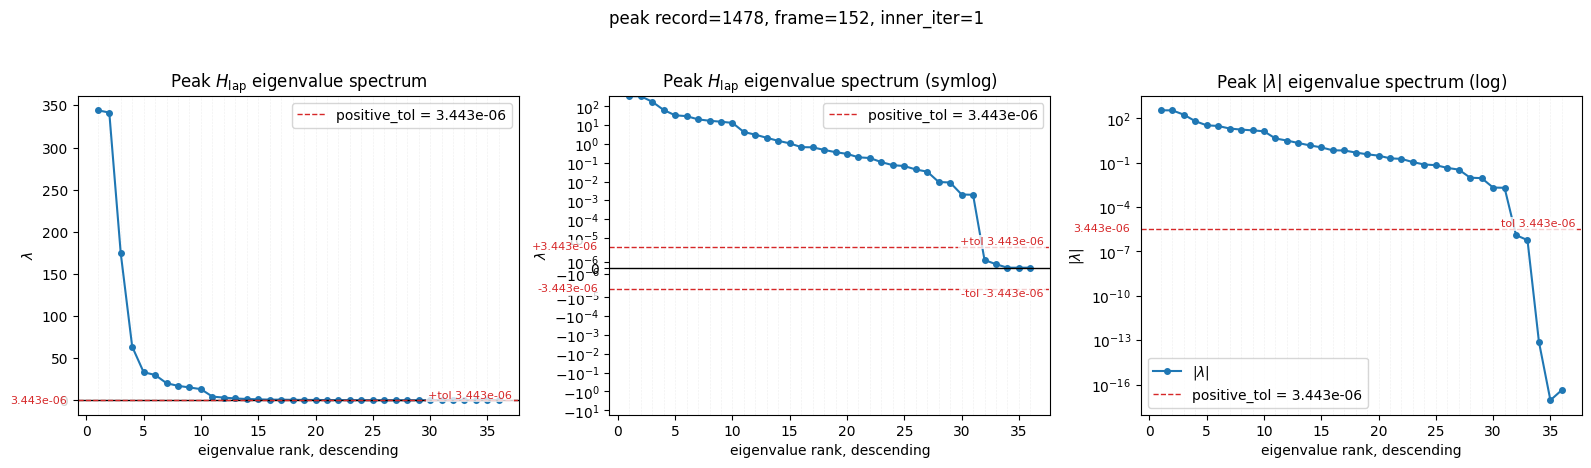

In [270]:
import matplotlib.pyplot as plt

evals_desc = evals_peak[::-1]
rank = np.arange(1, evals_desc.size + 1)
positive_tol = float(peak_spectrum_metrics["positive_tol"])
positive_tol_label = f"positive_tol = {positive_tol:.3e}"


def annotate_tol_line(ax, y, text, va="bottom"):
    ax.text(
        0.985,
        y,
        text,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va=va,
        color="tab:red",
        fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.5},
    )


def annotate_tol_axis(ax, y, text, va="center"):
    ax.text(
        -0.025,
        y,
        text,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va=va,
        color="tab:red",
        fontsize=8,
        clip_on=False,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 1.5},
    )


def add_rank_x_grid(ax, ranks):
    ax.grid(False)
    for x in ranks:
        ax.axvline(x, color="0.82", linestyle="--", linewidth=0.45, alpha=0.32, zorder=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(rank, evals_desc, marker="o", markersize=4, linewidth=1.5)
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(positive_tol, color="tab:red", linestyle="--", linewidth=1, label=positive_tol_label)
annotate_tol_line(ax, positive_tol, f"+tol {positive_tol:.3e}")
annotate_tol_axis(ax, positive_tol, f"{positive_tol:.3e}")
ax.set_title(r"Peak $H_{\mathrm{lap}}$ eigenvalue spectrum")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda$")
ax.legend()
add_rank_x_grid(ax, rank)

ax = axes[1]
ax.plot(rank, evals_desc, marker="o", markersize=4, linewidth=1.5)
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(positive_tol, color="tab:red", linestyle="--", linewidth=1, label=positive_tol_label)
ax.axhline(-positive_tol, color="tab:red", linestyle="--", linewidth=1)
annotate_tol_line(ax, positive_tol, f"+tol {positive_tol:.3e}")
annotate_tol_line(ax, -positive_tol, f"-tol {-positive_tol:.3e}", va="top")
annotate_tol_axis(ax, positive_tol, f"+{positive_tol:.3e}")
annotate_tol_axis(ax, -positive_tol, f"{-positive_tol:.3e}")
ax.set_yscale("symlog", linthresh=max(positive_tol, 1e-12))
ax.set_title(r"Peak $H_{\mathrm{lap}}$ eigenvalue spectrum (symlog)")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda$")
ax.legend()
add_rank_x_grid(ax, rank)

ax = axes[2]
abs_floor = max(positive_tol * 1e-12, np.finfo(float).tiny)
abs_evals_desc = np.maximum(np.abs(evals_desc), abs_floor)
ax.plot(rank, abs_evals_desc, marker="o", markersize=4, linewidth=1.5, label=r"$|\lambda|$")
ax.axhline(positive_tol, color="tab:red", linestyle="--", linewidth=1, label=positive_tol_label)
annotate_tol_line(ax, positive_tol, f"tol {positive_tol:.3e}")
annotate_tol_axis(ax, positive_tol, f"{positive_tol:.3e}")
ax.set_yscale("log")
ax.set_title(r"Peak $|\lambda|$ eigenvalue spectrum (log)")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$|\lambda|$")
ax.legend()
add_rank_x_grid(ax, rank)

fig.suptitle(
    f"peak record={peak_record_idx}, frame={peak_frame}, inner_iter={peak_inner_iter}",
    y=1.03,
)
plt.tight_layout()
plt.show()


## 3 全记录 Laplacian 谱

对所有 saved `lap` Hessian records 复用第 2 节指标，只看跨 frame / inner iteration 的曲率大小、最小正特征值、有效秩和 near-zero 数量。每条 record 的阈值 $\tau^{(r)}$ 都按自己的谱尺度单独计算。


In [271]:
def metric_series(evals_all, key):
    return np.array([hessian_spectrum_metrics(evals)[key] for evals in evals_all], dtype=float)


def print_series_summary(name, values):
    values = np.asarray(values, dtype=float).reshape(-1)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        print("{:34s} {:>14s} {:>14s}".format(name, "nan", "nan"))
        return
    print("{:34s} {:14.8g} {:14.8g}".format(name, float(np.min(finite)), float(np.max(finite))))


print("per-record H_lap spectrum summary")
print("{:34s} {:>14s} {:>14s}".format("metric", "min", "max"))
for key in ["lambda_max", "lambda_min_positive", "rank_eff", "near_zero_count"]:
    print_series_summary(key, metric_series(lap_evals_all, key))


per-record H_lap spectrum summary
metric                                        min            max
lambda_max                              183.99991      344.27106
lambda_min_positive                 1.0854809e-05   0.0020286704
rank_eff                                       30             31
near_zero_count                                 5              6


### 3.1 多记录特征值谱采样

按 `lambda_max` 选多个分位 records：p0、p10、p25、p50、p75、p90、p95、p99、p100。比较这些代表谱曲线。用 heatmap 查看全部 records 的谱结构。画所有 records 的 spectrum percentile band，判断谱结构是否整体稳定。


representative spectrum records
   pct   record   frame  iter     lambda_max  rank_eff  near_zero
   0.0      939      96     1      183.99991        31          5
  10.0      962      98     9      194.84365        31          5
  25.0      985     101     2      208.04465        31          5
  50.0     1785     183     3      284.94884        31          5
  75.0      304      27     0      317.56742        31          5
  90.0     1573     161     6      327.81067        31          5
  95.0     1453     149     6      331.34895        31          5
  99.0     1461     150     4      342.83017        31          5
 100.0     1478     152     1      344.27106        31          5


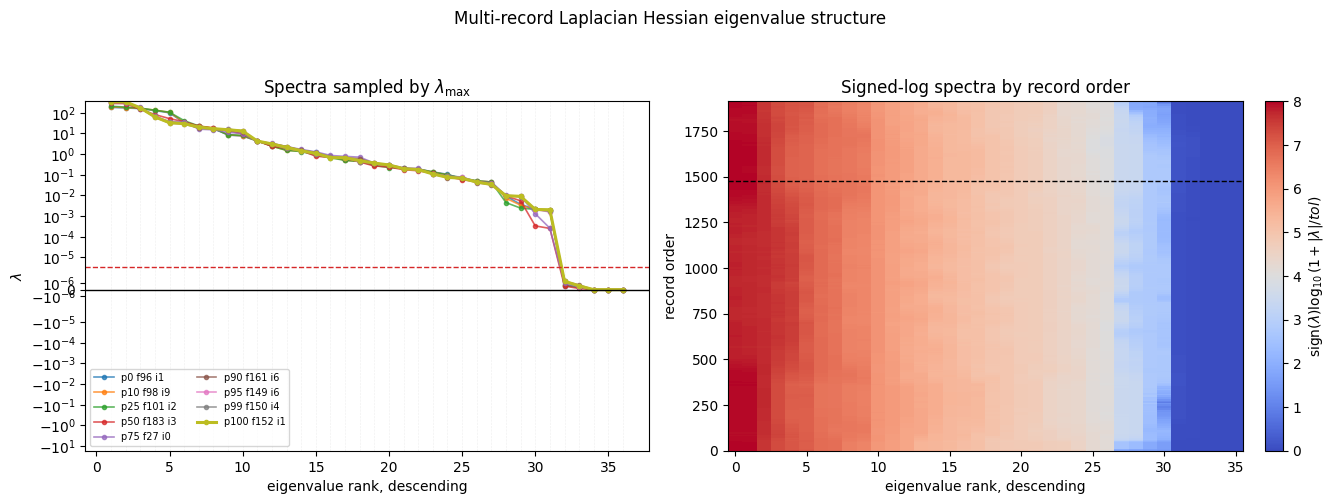

In [272]:
def nearest_quantile_records(values, percentiles):
    values = np.asarray(values, dtype=float).reshape(-1)
    finite = np.flatnonzero(np.isfinite(values))
    records = []
    if finite.size == 0:
        return records
    finite_values = values[finite]
    for pct in percentiles:
        target = float(np.nanpercentile(finite_values, pct))
        idx = int(finite[np.nanargmin(np.abs(finite_values - target))])
        records.append((float(pct), idx, target, float(values[idx])))
    return records


lambda_quantile_records = nearest_quantile_records(lap_lambda_max, [0, 10, 25, 50, 75, 90, 95, 99, 100])

print("representative spectrum records")
print(
    f"{'pct':>6s} {'record':>8s} {'frame':>7s} {'iter':>5s} "
    f"{'lambda_max':>14s} {'rank_eff':>9s} {'near_zero':>10s}"
)
for pct, idx, target, actual in lambda_quantile_records:
    metrics = hessian_spectrum_metrics(lap_evals_all[idx])
    print(
        f"{pct:6.1f} {idx:8d} {int(hessian_frame[idx]):7d} {int(hessian_inner_iter[idx]):5d} "
        f"{fmt_metric(metrics['lambda_max'])} "
        f"{fmt_metric(metrics['rank_eff'], width=9)} {fmt_metric(metrics['near_zero_count'], width=10)}"
    )

lap_evals_desc_all = lap_evals_all[:, ::-1]
eig_rank = np.arange(1, lap_evals_desc_all.shape[1] + 1)
positive_tol = float(peak_spectrum_metrics["positive_tol"])
linthresh = max(positive_tol, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
for pct, idx, target, actual in lambda_quantile_records:
    is_peak = idx == peak_record_idx
    ax.plot(
        eig_rank,
        lap_evals_desc_all[idx],
        marker="o",
        markersize=3,
        linewidth=2.2 if is_peak else 1.2,
        alpha=1.0 if is_peak else 0.75,
        label=f"p{pct:g} f{int(hessian_frame[idx])} i{int(hessian_inner_iter[idx])}",
    )
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(positive_tol, color="tab:red", linestyle="--", linewidth=1)
ax.set_yscale("symlog", linthresh=linthresh)
ax.set_title(r"Spectra sampled by $\lambda_{\max}$")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda$")
ax.legend(fontsize=7, ncol=2)
add_rank_x_grid(ax, eig_rank)

ax = axes[1]
record_order = np.arange(lap_evals_desc_all.shape[0])
signed_log_evals = np.sign(lap_evals_desc_all) * np.log10(1.0 + np.abs(lap_evals_desc_all) / linthresh)
image = ax.imshow(
    signed_log_evals[record_order],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="coolwarm",
)
ax.axhline(peak_record_idx, color="black", linestyle="--", linewidth=1)
ax.set_title("Signed-log spectra by record order")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel("record order")
cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"sign$(\lambda)\log_{10}(1 + |\lambda| / tol)$")

fig.suptitle("Multi-record Laplacian Hessian eigenvalue structure", y=1.04)
plt.tight_layout()
plt.show()


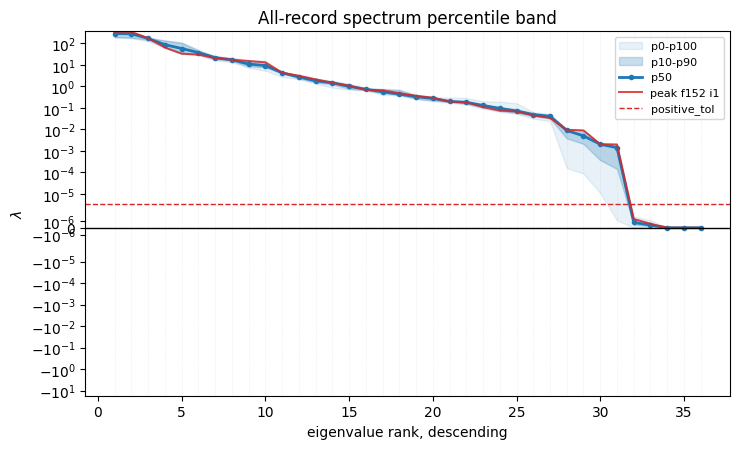

In [273]:
lap_evals_desc_all = lap_evals_all[:, ::-1]
eig_rank = np.arange(1, lap_evals_desc_all.shape[1] + 1)
positive_tol = float(peak_spectrum_metrics["positive_tol"])
linthresh = max(positive_tol, 1e-12)

p0, p10, p50, p90, p100 = np.nanpercentile(
    lap_evals_desc_all,
    [0, 10, 50, 90, 100],
    axis=0,
)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.fill_between(eig_rank, p0, p100, color="tab:blue", alpha=0.10, label="p0-p100")
ax.fill_between(eig_rank, p10, p90, color="tab:blue", alpha=0.24, label="p10-p90")
ax.plot(eig_rank, p50, color="tab:blue", marker="o", markersize=3, linewidth=2.0, label="p50")
ax.plot(
    eig_rank,
    lap_evals_desc_all[peak_record_idx],
    color="tab:red",
    linewidth=1.4,
    alpha=0.85,
    label=f"peak f{int(hessian_frame[peak_record_idx])} i{int(hessian_inner_iter[peak_record_idx])}",
)
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(positive_tol, color="tab:red", linestyle="--", linewidth=1, label="positive_tol")
ax.set_yscale("symlog", linthresh=linthresh)
ax.set_title("All-record spectrum percentile band")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda$")
ax.legend(fontsize=8)
add_rank_x_grid(ax, eig_rank)

plt.tight_layout()
plt.show()


## 4 大特征方向来源：变量块与 Rayleigh 分解

对 Hessian 的最大特征向量 $u_{\max}$：

对向量 $u$ 的 index 按照 block 分组，算 $\sum_{i\in \mathrm{block}}u_i^2$：

- `base_xyz`: `q[0:3]`，floating base 平移 xyz。
- `base_quat`: `q[3:7]`，floating base quaternion 四个分量。
- `floating_base_total`: `q[0:7]`，即 `base_xyz + base_quat`。
- `robot_joint_total`: `q[7:nq]`，所有机器人关节变量。
- `leg_joint_approx_q7_18`: `q[7:19]`，近似腿部关节块。
- `waist_joint_approx_q19_21`: `q[19:22]`，近似腰部关节块。
- `upper_body_joint_approx_q22_end`: `q[22:nq]`，近似上身关节块。

Rayleigh quotient 分解看 Hessian energy 从哪里来。做 base / joint 拆分：

$$
q=\begin{bmatrix}q_b\\q_j\end{bmatrix},\qquad
q_b=q[0:7],\qquad q_j=q[7:nq].
$$

Hessian $H_{\mathrm{lap}}$ 按同样的行列 index 分成四块：

$$
H_{\mathrm{lap}}=
\begin{bmatrix}
H_{bb} & H_{bj}\\
H_{jb} & H_{jj}
\end{bmatrix},
$$


$$
\lambda_{\max}=u_b^TH_{bb}u_b+2u_b^TH_{bj}u_j+u_j^TH_{jj}u_j.
$$




In [274]:
lambda_max_peak = float(evals_peak[-1])
u_max_peak = evecs_peak[:, -1]
nq_a = H_lap_peak.shape[0]

blocks = {
    "base_xyz": slice(0, min(3, nq_a)),
    "base_quat": slice(3, min(7, nq_a)),
    "floating_base_total": slice(0, min(7, nq_a)),
    "robot_joint_total": slice(min(7, nq_a), nq_a),
    "leg_joint_approx_q7_18": slice(7, min(19, nq_a)),
    "waist_joint_approx_q19_21": slice(19, min(22, nq_a)),
    "upper_body_joint_approx_q22_end": slice(22, nq_a),
}
block_descriptions = {
    "base_xyz": "base translation xyz",
    "base_quat": "base quaternion",
    "floating_base_total": "base_xyz + base_quat",
    "robot_joint_total": "all robot joints",
    "leg_joint_approx_q7_18": "leg joints",
    "waist_joint_approx_q19_21": "waist joints",
    "upper_body_joint_approx_q22_end": "upper-body joints",
}


def block_sqnorm_fractions(u, blocks):
    return {
        name: float(np.sum(u[sl] ** 2))
        for name, sl in blocks.items()
        if sl.start < sl.stop
    }


def dominant_block_name(fractions, candidate_names):
    candidates = [(name, fractions[name]) for name in candidate_names if name in fractions]
    return max(candidates, key=lambda item: item[1])[0] if candidates else "none"


FINE_BLOCK_NAMES = [
    "base_xyz",
    "base_quat",
    "leg_joint_approx_q7_18",
    "waist_joint_approx_q19_21",
    "upper_body_joint_approx_q22_end",
]


def print_block_definitions(blocks, descriptions):
    print("block definitions")
    print(f"{'block':34s} {'q_slice':>9s} {'dim':>4s}  contains")
    for name, sl in blocks.items():
        if sl.start < sl.stop:
            print(f"{name:34s} {q_slice_text(sl):>9s} {sl.stop - sl.start:4d}  {descriptions[name]}")


def q_slice_text(sl):
    return f"q[{sl.start}:{sl.stop}]"


def H_slice_text(row_sl, col_sl):
    return f"H[{row_sl.start}:{row_sl.stop}, {col_sl.start}:{col_sl.stop}]"


def print_hessian_block_definitions(H, base_sl, joint_sl):
    h_blocks = [
        ("Hbb", base_sl, base_sl, "base-base curvature"),
        ("Hbj", base_sl, joint_sl, "base-joint coupling"),
        ("Hjb", joint_sl, base_sl, "joint-base coupling = Hbj.T"),
        ("Hjj", joint_sl, joint_sl, "joint-joint curvature"),
    ]
    print("H block definitions for Rayleigh split")
    print(f"{'block':4s} {'rows':>9s} {'cols':>9s} {'H_slice':>18s} {'shape':>8s}  meaning")
    for name, row_sl, col_sl, meaning in h_blocks:
        shape = H[row_sl, col_sl].shape
        print(
            f"{name:4s} {q_slice_text(row_sl):>9s} {q_slice_text(col_sl):>9s} "
            f"{H_slice_text(row_sl, col_sl):>18s} {shape[0]:3d}x{shape[1]:<3d}  {meaning}"
        )


def print_block_fractions(title, fractions):
    print(title)
    print(f"{'block':34s} {'fraction':>12s}")
    for name, value in fractions.items():
        print(f"{name:34s} {value:12.8f}")


def print_mode_block_table(title, evals, evecs, indices, blocks):
    print(title)
    print(f"{'mode':>4s} {'eig':>4s} {'lambda':>13s} {'base':>10s} {'joint':>10s}  top_block")
    for mode, eig_index in enumerate(indices, start=1):
        fractions = block_sqnorm_fractions(evecs[:, eig_index], blocks)
        print(
            f"{mode:4d} {eig_index:4d} {evals[eig_index]:13.8f} "
            f"{fractions.get('floating_base_total', float('nan')):10.6f} "
            f"{fractions.get('robot_joint_total', float('nan')):10.6f}  "
            f"{dominant_block_name(fractions, FINE_BLOCK_NAMES)}"
        )


print(f"lambda_max(H_lap peak): {lambda_max_peak:.8f}")
print(f"active q dimension: {nq_a}")
print()
print_block_definitions(blocks, block_descriptions)

print()
print_block_fractions(
    "largest-eigenvector block fractions",
    block_sqnorm_fractions(u_max_peak, blocks),
)

base_sl = blocks["floating_base_total"]
joint_sl = blocks["robot_joint_total"]
base = np.arange(base_sl.start, base_sl.stop)
robot_joint = np.arange(joint_sl.start, joint_sl.stop)
stiff_indices = list(range(nq_a - 1, max(nq_a - 6, -1), -1))

print()
print_mode_block_table("top stiff-direction block fractions", evals_peak, evecs_peak, stiff_indices, blocks)

print()
print_hessian_block_definitions(H_lap_peak, base_sl, joint_sl)

Hbb = H_lap_peak[np.ix_(base, base)]
Hbj = H_lap_peak[np.ix_(base, robot_joint)]
Hjj = H_lap_peak[np.ix_(robot_joint, robot_joint)]
ub = u_max_peak[base]
uj = u_max_peak[robot_joint]

rayleigh_terms = {
    "base-base": float(ub @ Hbb @ ub) if base.size else 0.0,
    "base-joint coupling": float(2.0 * ub @ Hbj @ uj) if (base.size and robot_joint.size) else 0.0,
    "joint-joint": float(uj @ Hjj @ uj) if robot_joint.size else 0.0,
}
rayleigh_sum = sum(rayleigh_terms.values())

print()
print("Rayleigh quotient at lambda_max eigenvector")
print(f"coarse split: base={q_slice_text(base_sl)}, joint={q_slice_text(joint_sl)}")
print(f"{'term':24s} {'value':>13s} {'frac':>10s}")
for name, value in rayleigh_terms.items():
    frac = value / lambda_max_peak if lambda_max_peak != 0 else float("nan")
    print(f"{name:24s} {value:13.8f} {frac:10.6f}")
print(f"{'sum':24s} {rayleigh_sum:13.8f} {rayleigh_sum / lambda_max_peak:10.6f}")
print(f"{'lambda_max':24s} {lambda_max_peak:13.8f}")
print(f"abs(sum - lambda_max): {abs(rayleigh_sum - lambda_max_peak):.3e}")


lambda_max(H_lap peak): 344.27105976
active q dimension: 36

block definitions
block                                q_slice  dim  contains
base_xyz                              q[0:3]    3  base translation xyz
base_quat                             q[3:7]    4  base quaternion
floating_base_total                   q[0:7]    7  base_xyz + base_quat
robot_joint_total                    q[7:36]   29  all robot joints
leg_joint_approx_q7_18               q[7:19]   12  leg joints
waist_joint_approx_q19_21           q[19:22]    3  waist joints
upper_body_joint_approx_q22_end     q[22:36]   14  upper-body joints

largest-eigenvector block fractions
block                                  fraction
base_xyz                             0.45458640
base_quat                            0.49066331
floating_base_total                  0.94524972
robot_joint_total                    0.05475028
leg_joint_approx_q7_18               0.01393138
waist_joint_approx_q19_21            0.03589000
upper_body_joi

### 跨 record 的最大特征向量 block fraction

按每条 record 的 $\lambda_{\max}$ 取百分位代表点。对每条代表 record，取它自己的最大特征向量 $u_{\max}^{(r)}$，并计算：

$$
E_B^{(r)}=\sum_{i\in B}\left(u_{\max,i}^{(r)}\right)^2.
$$

`base_xyz`、`base_quat`、`base`、`joint` 是对应 block 的 $E_B^{(r)}$；`top_block` 是占比最大的细变量块。


In [275]:
print("largest-eigenvector block fractions across lambda_max quantile records")
print(
    f"{'pct':>5s} {'rec':>5s} {'f':>4s} {'i':>3s} {'lambda_max':>12s} "
    f"{'base_xyz':>9s} {'base_quat':>9s} {'base':>9s} {'joint':>9s}  top_block"
)
for pct, idx, target, actual in lambda_quantile_records:
    evals_record, evecs_record = np.linalg.eigh(lap_mats[idx])
    fractions = block_sqnorm_fractions(evecs_record[:, -1], blocks)
    print(
        f"{pct:5.1f} {idx:5d} {int(hessian_frame[idx]):4d} {int(hessian_inner_iter[idx]):3d} "
        f"{evals_record[-1]:12.6f} "
        f"{fractions.get('base_xyz', float('nan')):9.6f} "
        f"{fractions.get('base_quat', float('nan')):9.6f} "
        f"{fractions.get('floating_base_total', float('nan')):9.6f} "
        f"{fractions.get('robot_joint_total', float('nan')):9.6f}  "
        f"{dominant_block_name(fractions, FINE_BLOCK_NAMES)}"
    )


largest-eigenvector block fractions across lambda_max quantile records
  pct   rec    f   i   lambda_max  base_xyz base_quat      base     joint  top_block
  0.0   939   96   1   183.999915  0.707130  0.268356  0.975486  0.024514  base_xyz
 10.0   962   98   9   194.843655  0.647706  0.324396  0.972102  0.027898  base_xyz
 25.0   985  101   2   208.044647  0.602581  0.365190  0.967771  0.032229  base_xyz
 50.0  1785  183   3   284.948841  0.398605  0.555302  0.953907  0.046093  base_quat
 75.0   304   27   0   317.567421  0.534323  0.415710  0.950032  0.049968  base_xyz
 90.0  1573  161   6   327.810669  0.466499  0.478594  0.945093  0.054907  base_quat
 95.0  1453  149   6   331.348946  0.443893  0.500878  0.944771  0.055229  base_quat
 99.0  1461  150   4   342.830165  0.449350  0.496164  0.945515  0.054485  base_quat
100.0  1478  152   1   344.271060  0.454586  0.490663  0.945250  0.054750  base_quat


### Block energy

peak Hessian 第 $k$ 大特征值对应的特征向量 $u_k$。每个 block 输出：

$$
E_B(k)=\sum_{i\in B}u_{k,i}^2.
$$

`rank=1` 是最大特征值方向，`rank=2` 是第二大特征值方向，依此类推。


In [276]:
print("individual stiff-direction block energy at peak record")
print(
    f"{'rank':>4s} {'eig':>4s} {'lambda':>12s} {'base_xyz':>9s} {'base_quat':>9s} "
    f"{'base':>9s} {'joint':>9s}  top_block"
)
for rank in [1, 2, 3, 5, 10]:
    eig_index = nq_a - rank
    if eig_index < 0:
        continue
    energy = block_sqnorm_fractions(evecs_peak[:, eig_index], blocks)
    print(
        f"{rank:4d} {eig_index:4d} {evals_peak[eig_index]:12.6f} "
        f"{energy.get('base_xyz', float('nan')):9.6f} "
        f"{energy.get('base_quat', float('nan')):9.6f} "
        f"{energy.get('floating_base_total', float('nan')):9.6f} "
        f"{energy.get('robot_joint_total', float('nan')):9.6f}  "
        f"{dominant_block_name(energy, FINE_BLOCK_NAMES)}"
    )


individual stiff-direction block energy at peak record
rank  eig       lambda  base_xyz base_quat      base     joint  top_block
   1   35   344.271060  0.454586  0.490663  0.945250  0.054750  base_quat
   2   34   341.583047  0.460839  0.488312  0.949151  0.050849  base_quat
   3   33   174.487026  0.992736  0.000008  0.992744  0.007256  base_xyz
   5   31    33.216057  0.423533  0.391753  0.815286  0.184714  base_xyz
  10   26    13.127426  0.003835  0.047834  0.051669  0.948331  leg_joint_approx_q7_18


## 5 Near-zero 特征值诊断

符号定义：

- $q\in\mathbb{R}^{n_q}$：active optimization variables。
- $V(q)=[v_1(q)^T,\ldots,v_N(q)^T]^T\in\mathbb{R}^{3N}$：Laplacian 使用的 interaction vertices。
- $J_V=\partial V/\partial q\in\mathbb{R}^{3N\times n_q}$：vertices 对 $q$ 的 Jacobian。
- $L\in\mathbb{R}^{N\times N}$：interaction mesh Laplacian。
- $c\in\mathbb{R}^{3N}$：demo/source interaction mesh 的目标 Laplacian coordinates；对当前优化变量 $q$ 是常量。
- $r_{\mathrm{lap}}(q)=(L\otimes I_3)V(q)-c$：当前 Laplacian coordinates 与目标 $c$ 的差。
- $J_{\mathrm{lap}}=\partial r_{\mathrm{lap}}/\partial q=(L\otimes I_3)J_V$：Laplacian residual 对 $q$ 的 Jacobian。
- $W=\operatorname{diag}(w_m)$：residual row weights。

$$
H_{\mathrm{lap}}=2J_{\mathrm{lap}}^TWJ_{\mathrm{lap}},\qquad A=W^{1/2}J_{\mathrm{lap}}.
$$

$$
H_{\mathrm{lap}}=2A^TA.
$$

对单位特征向量 $u_i$：

$$
\lambda_i=u_i^TH_{\mathrm{lap}}u_i=2\|W^{1/2}J_{\mathrm{lap}}u_i\|^2.
$$

near-zero eigenvalue 对应 $W^{1/2}J_{\mathrm{lap}}u_i\approx0$。


### 5.1 读取 exact saved $J_{\mathrm{lap}}$

从 Hessian sidecar 读取与 `peak_record_idx` 同一条 Hessian record 保存的 $J_V$、$J_{\mathrm{lap}}$ 和 $W$：

$$
H_{\mathrm{lap}}=2J_{\mathrm{lap}}^TWJ_{\mathrm{lap}}.
$$


In [277]:
def symmetrize(H):
    H = np.asarray(H, dtype=float)
    return 0.5 * (H + H.T)


def hessian_from_jacobian(J, weights):
    J = np.asarray(J, dtype=float)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    return symmetrize(2.0 * (J.T @ (weights[:, None] * J)))


REQUIRED_LAP_DIAGNOSTIC_FIELDS = [
    "hessian_q_active",
    "hessian_q_eval",
    "hessian_lap_J_V",
    "hessian_lap_J_lap",
    "hessian_lap_weights",
]
missing_lap_diagnostic_fields = [key for key in REQUIRED_LAP_DIAGNOSTIC_FIELDS if key not in hessian_data.files]
if missing_lap_diagnostic_fields:
    raise KeyError(f"Missing exact Laplacian diagnostic fields: {missing_lap_diagnostic_fields}")

q_active_peak = np.asarray(hessian_data["hessian_q_active"][peak_record_idx], dtype=float)
q_eval_peak = np.asarray(hessian_data["hessian_q_eval"][peak_record_idx], dtype=float)
lap_diag_J_V = np.asarray(hessian_data["hessian_lap_J_V"][peak_record_idx], dtype=float)
lap_diag_J_lap = np.asarray(hessian_data["hessian_lap_J_lap"][peak_record_idx], dtype=float)
lap_diag_weights = np.asarray(hessian_data["hessian_lap_weights"][peak_record_idx], dtype=float).reshape(-1)

lap_diag_H = hessian_from_jacobian(lap_diag_J_lap, lap_diag_weights)
lap_diag_evals, lap_diag_evecs = np.linalg.eigh(lap_diag_H)
lap_diag_lambda_max = float(lap_diag_evals[-1])

print("diagnosis record:", peak_record_idx)
print("diagnosis frame:", peak_frame)
print("diagnosis inner_iter:", peak_inner_iter)
print("q_active shape:", q_active_peak.shape)
print("q_eval shape:", q_eval_peak.shape)
print("J_V shape:", lap_diag_J_V.shape)
print("J_lap shape:", lap_diag_J_lap.shape)
print("weights shape:", lap_diag_weights.shape)
print("saved lambda_max(H_lap):", saved_lambda_max)
print("lambda_max(2 J_lap.T W J_lap):", lap_diag_lambda_max)
print("max abs H diff:", float(np.max(np.abs(lap_diag_H - H_lap_peak))))


diagnosis record: 1478
diagnosis frame: 152
diagnosis inner_iter: 1
q_active shape: (36,)
q_eval shape: (43,)
J_V shape: (345, 36)
J_lap shape: (345, 36)
weights shape: (345,)
saved lambda_max(H_lap): 344.27105976397644
lambda_max(2 J_lap.T W J_lap): 344.2710597639767
max abs H diff: 0.0


### 5.2 Near-zero diagnostics

对诊断用 $H_{\mathrm{lap}}$ 的第 $i$ 个 near-zero mode $u_i$：

$$
\Delta V_i = J_V u_i,\qquad \Delta r_i = J_{\mathrm{lap}}u_i=(L\otimes I_3)\Delta V_i.
$$

$$
\widehat{\lambda}_i = 2\|W^{1/2}\Delta r_i\|_2^2.
$$

记录这些量用于区分 near-zero 来源：

- `Jv_norm`: $\|\Delta V_i\|_2$，检查 $J_Vu_i\approx0$。
- `lap_gain`: $\|\Delta r_i\|_2 / \|\Delta V_i\|_2$，Laplacian 对 vertex displacement 的范数放大/压缩比例。
- `weighted_Jlap_norm`: $\|W^{1/2}\Delta r_i\|_2$，直接决定 $\widehat{\lambda}_i$。
- `lambda_from_J`: $\widehat{\lambda}_i$。


In [278]:
def safe_divide(numerator, denominator, tol=1e-300):
    denominator = float(denominator)
    return float("nan") if abs(denominator) <= tol else float(numerator) / denominator


lap_diag_positive_tol = eigenvalue_positive_tol(lap_diag_evals)
lap_diag_near_zero_indices = np.flatnonzero(lap_diag_evals <= lap_diag_positive_tol)

print("near-zero mode diagnostics")
print("positive_tol:", lap_diag_positive_tol)
print(
    f"{'eig':>4s} {'lambda':>14s} {'lambda_from_J':>14s} {'Jv_norm':>11s} "
    f"{'Jlap_norm':>11s} {'weighted_Jlap_norm':>20s} {'lap_gain':>10s}"
)
for eig_index in lap_diag_near_zero_indices:
    u = lap_diag_evecs[:, eig_index]
    dV = lap_diag_J_V @ u
    dlap = lap_diag_J_lap @ u
    weighted_dlap = np.sqrt(lap_diag_weights) * dlap
    Jv_norm = float(np.linalg.norm(dV))
    Jlap_norm = float(np.linalg.norm(dlap))
    weighted_Jlap_norm = float(np.linalg.norm(weighted_dlap))
    lambda_from_J = 2.0 * weighted_Jlap_norm**2
    lap_gain = safe_divide(Jlap_norm, Jv_norm)
    print(
        f"{eig_index:4d} {lap_diag_evals[eig_index]:14.8e} {lambda_from_J:14.8e} "
        f"{Jv_norm:11.4e} {Jlap_norm:11.4e} {weighted_Jlap_norm:20.4e} "
        f"{lap_gain:10.4e}"
    )


near-zero mode diagnostics
positive_tol: 3.4427105976397673e-06
 eig         lambda  lambda_from_J     Jv_norm   Jlap_norm   weighted_Jlap_norm   lap_gain
   0 -4.28614978e-17 2.75513261e-27  1.1245e-14  1.1737e-14           3.7116e-14 1.0437e+00
   1 8.73384197e-18 1.97917634e-28  3.0923e-15  3.1458e-15           9.9478e-15 1.0173e+00
   2 7.63317549e-14 5.57351210e-25  1.5850e-13  1.6694e-13           5.2790e-13 1.0532e+00
   3 5.75816704e-07 5.75816704e-07  1.6308e-04  1.6968e-04           5.3657e-04 1.0405e+00
   4 1.26619457e-06 1.26619457e-06  2.5996e-04  2.5161e-04           7.9567e-04 9.6788e-01
